# SSFM Validation - Imported Ground Truth Solver

**Project**: PINN-NLSE  
**Purpose**: SSFM validation and ground-truth dataset generation

This notebook demonstrates that the Split-Step Fourier Method (SSFM) solver,
**imported from the companion project** `../2-Split_Step_Fourier_Solver/`, works
correctly inside this PINN repository. It also generates the ground-truth
`.npz` datasets used to train and validate the PINN.

**Convention** (Agrawal): `s = -sign(beta_2)`. For anomalous dispersion (`beta_2 < 0`), `s = +1`.

**Normalized NLSE**:
$$ i\,\frac{\partial u}{\partial \xi} + \frac{s}{2}\frac{\partial^2 u}{\partial \tau^2} + N^2\,|u|^2\,u \;=\; 0 $$

**Sections**:
1. Setup & imports
2. N=1 fundamental soliton (acid test)
3. Energy conservation check
4. Step-size convergence study (2nd-order Strang)
5. Gaussian dispersion-only broadening (analytical comparison)
6. Self-phase modulation (spectral broadening)
7. Optional: Gaussian + anomalous + Kerr (harder PINN test)
8. Summary

**Reproducibility**: if any required `data/*.npz` file is missing, this notebook
will regenerate it inline by calling `src.generate_ground_truth.generate_all`.


In [1]:
import json
import os
import sys
from pathlib import Path

# When run from notebooks/, ensure project root is on sys.path so `from src...` works.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

from src.config import (
    FIGURE_PATHS, N_SOLITON, N_T, N_Z, S_SIGN, TAU_MAX, XI_MAX,
)
from src.nlse_utils import (
    create_grid, sech_pulse, gaussian_pulse, compute_energy, compute_spectrum,
)
from src.ssfm import ssfm_propagate
from src.utils import plot_propagation_map, plot_spectrum_evolution
from src.generate_ground_truth import generate_all
from src.data_gen import load_ground_truth_npz

REQUIRED_NPZS = [
    'data/soliton_ground_truth.npz',
    'data/dispersion_broadening_ground_truth.npz',
    'data/spm_ground_truth.npz',
]
OPTIONAL_NPZ = 'data/gaussian_nonlinear_ground_truth.npz'

missing = [p for p in REQUIRED_NPZS if not Path(p).exists()]
if missing or not Path(OPTIONAL_NPZ).exists():
    print('Regenerating missing ground-truth datasets...')
    generate_all(include_optional=True)
else:
    print('All ground-truth datasets present:', REQUIRED_NPZS, OPTIONAL_NPZ)

tau, omega, dtau = create_grid(N_t=N_T, tau_window=TAU_MAX)
print(f'Grid: N_T={N_T}, tau_window={TAU_MAX}, dtau={dtau:.6f}, N_z={N_Z}, xi_max={XI_MAX}')


All ground-truth datasets present: ['data/soliton_ground_truth.npz', 'data/dispersion_broadening_ground_truth.npz', 'data/spm_ground_truth.npz'] data/gaussian_nonlinear_ground_truth.npz
Grid: N_T=1024, tau_window=20.0, dtau=0.039062, N_z=1000, xi_max=5.0


## 2. N=1 fundamental soliton â€” the acid test

The N=1 soliton is the canonical exact solution of the normalized NLSE in anomalous
dispersion (s=+1). Starting from `u(0,Ï„) = sech(Ï„)`, the analytical solution is:

$$ u(\xi, \tau) = \mathrm{sech}(\tau)\, e^{i\xi/2} $$

The **intensity profile is invariant in Î¾** because anomalous GVD and Kerr
nonlinearity exactly balance. The complex field acquires a uniform global phase
`exp(iÎ¾/2)` â€” note this is *not* a recurrence period but a steady accumulation.

What we check below:
- **Max complex error** vs `sech(Ï„)Â·exp(iÎ¾/2)` should be < 1e-3 at the default grid
  and < 1e-6 with N_z = 2000 (Strang is `O(dÎ¾Â²)`).
- **Max intensity error** ||u|Â² âˆ’ sechÂ²(Ï„)| should match the same `O(dÎ¾Â²)` budget.


Bulk soliton (N_z=1000, xi_max=5):
  max complex error = 1.109e-05
  max intensity error = 3.894e-06


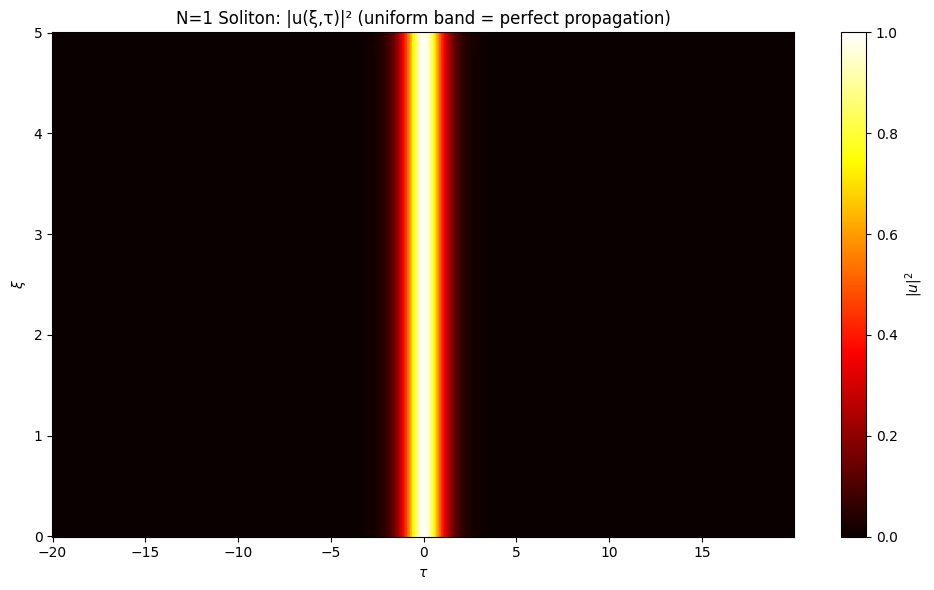

In [2]:
soliton = load_ground_truth_npz('data/soliton_ground_truth.npz')
u_hist = soliton['u_hist']
xi_arr = soliton['xi']
u_exact = sech_pulse(tau)[None, :] * np.exp(0.5j * xi_arr[:, None])
complex_err = float(np.max(np.abs(u_hist - u_exact)))
intensity_err = float(np.max(np.abs(np.abs(u_hist)**2 - np.abs(u_exact)**2)))
print(f'Bulk soliton (N_z=1000, xi_max=5):')
print(f'  max complex error = {complex_err:.3e}')
print(f'  max intensity error = {intensity_err:.3e}')

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(tau, xi_arr, np.abs(u_hist)**2, shading='auto', cmap='hot')
ax.set_xlabel(r'$\tau$'); ax.set_ylabel(r'$\xi$')
ax.set_title('N=1 Soliton: |u(\u03be,\u03c4)|\u00b2 (uniform band = perfect propagation)')
fig.colorbar(im, ax=ax, label=r'$|u|^2$')
plt.tight_layout(); plt.show()


## 3. Energy conservation

The NLSE conserves $E = \int |u|^2\,d\tau$. This is exactly analogous to
probability conservation $\int |\psi|^2\,dx = 1$ in QM: each Strang substep is a
unitary multiplication by a unit-modulus phase factor (`exp(âˆ’iÂ·sÂ·Ï‰Â²Â·dÎ¾/2)` in
frequency space, `exp(+iÂ·NÂ²|u|Â²Â·dÎ¾)` in time space), so the L2 norm is preserved
to machine precision. Drift > ~1e-10 indicates a bug.


E(0) = 2.000000  (analytical sech^2 integral = 2.0)
max |E(Î¾)/E(0) - 1| = 3.67e-13


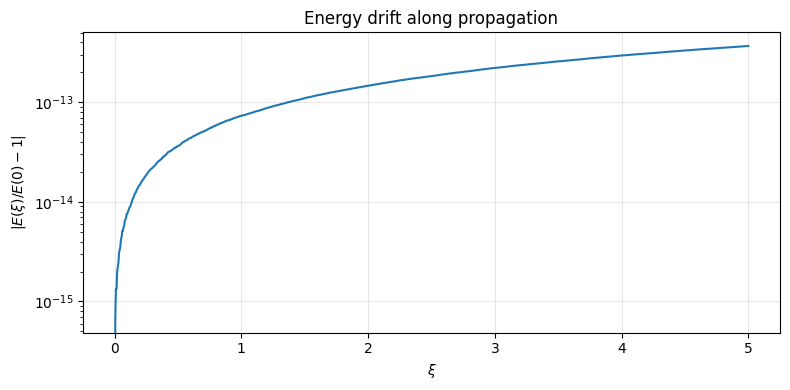

In [3]:
E0 = compute_energy(u_hist[0], dtau)
energies = np.array([compute_energy(u_hist[i], dtau) for i in range(len(xi_arr))])
drift = np.abs(energies / E0 - 1.0)
print(f'E(0) = {E0:.6f}  (analytical sech^2 integral = 2.0)')
print(f'max |E(\u03be)/E(0) - 1| = {np.max(drift):.2e}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xi_arr, drift, lw=1.5)
ax.set_xlabel(r'$\xi$'); ax.set_ylabel(r'$|E(\xi)/E(0) - 1|$')
ax.set_yscale('log')
ax.set_title('Energy drift along propagation')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 4. Step-size convergence (2nd-order Strang)

The symmetric Strang split-step scheme is **second-order accurate** in `dÎ¾`:
halving `dÎ¾` should reduce the error by ~4Ã— (and quadruple the steps `N_z` reduces
it by ~16Ã—). We sweep `N_z âˆˆ {100, 200, 400, 800, 1600}` and fit the slope on
logâ€“log axes; the fit excludes any saturated points (numerical floor or temporal
discretization). Target slope: â‰ˆ 2.


Fitted slope: 2.00  (target ~2.0)
N_z used in fit: [100, 200, 400, 800, 1600]


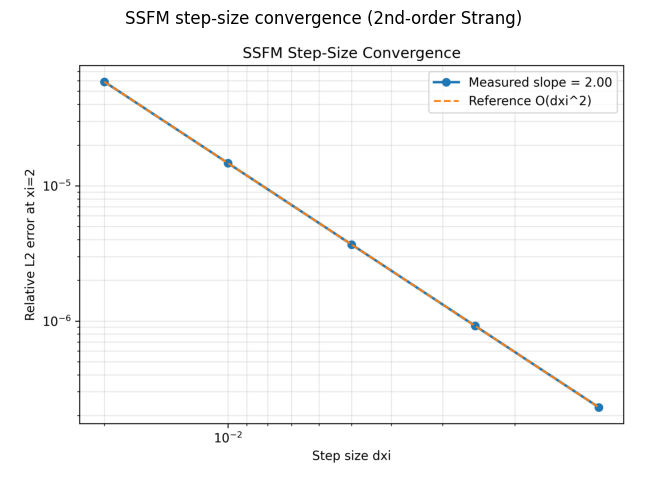

In [4]:
with open('data/ssfm_validation_metrics.json', 'r', encoding='utf-8') as f:
    metrics = json.load(f)
print(f"Fitted slope: {metrics['fitted_slope']:.2f}  (target ~2.0)")
print(f"N_z used in fit: {metrics['slope_fit_Nz_values']}")

from PIL import Image
fig, ax = plt.subplots(figsize=(7, 5))
img = Image.open('figures/ssfm_convergence_study.png')
ax.imshow(img); ax.axis('off')
ax.set_title('SSFM step-size convergence (2nd-order Strang)')
plt.tight_layout(); plt.show()
